# Distribution Metrics for Test vs Generated Samples

Ноутбук сравнивает распределение реальных полей из `test` и `1000` сгенерированных samples.

Что считается:
- пиксельные гистограммы по каждому каналу
- квантили по каждому каналу
- распределения image-level mean по каждому каналу
- распределения image-level std по каждому каналу
- компактная таблица с базовыми summary statistics


In [4]:
import json
import math
import os
import platform
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if platform.system() == 'Darwin':
    REPO_DIR = '/Users/amir/sciml/diffusion_data_assimilation'
    DATA_ROOT = '/Users/amir/sciml/sea_ice_data'
else:
    REPO_DIR = os.getcwd()
    DATA_ROOT = '/mnt/sciml/a.sadreev/sea_ice_data'

os.chdir(REPO_DIR)

REAL_DIR = os.path.join(DATA_ROOT, 'train')
FAKE_DIR = '/mnt/sciml/a.sadreev/sea_ice_data/inception_fid_test_eval/fake_test_subset_concat'
MASK_PATH = os.path.join(DATA_ROOT, 'mask_padding.npy')

CHANNEL_NAMES = ['channel_0', 'channel_1']
PIXEL_SAMPLE_SIZE = 200_000
HIST_BINS = 80
QUANTILES = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
RNG_SEED = 1234
NUM_WORKERS = min(16, os.cpu_count() or 4)

print('repo_dir        =', REPO_DIR)
print('real_dir        =', REAL_DIR)
print('fake_dir        =', FAKE_DIR)
print('mask_path       =', MASK_PATH)
print('pixel_sample_size =', PIXEL_SAMPLE_SIZE)
print('num_workers     =', NUM_WORKERS)


repo_dir        = /home
real_dir        = /mnt/sciml/a.sadreev/sea_ice_data/train
fake_dir        = /mnt/sciml/a.sadreev/sea_ice_data/inception_fid_test_eval/fake_test_subset_concat
mask_path       = /mnt/sciml/a.sadreev/sea_ice_data/mask_padding.npy
pixel_sample_size = 200000
num_workers     = 16


In [5]:
def to_channel_first(arr: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr)
    if arr.ndim == 2:
        return arr[None, ...].astype(np.float32, copy=False)
    if arr.ndim != 3:
        raise ValueError(f'Unsupported array shape {arr.shape}')
    if arr.shape[0] in (1, 2, 3):
        out = arr
    elif arr.shape[-1] in (1, 2, 3):
        out = np.moveaxis(arr, -1, 0)
    else:
        raise ValueError(f'Unsupported array shape {arr.shape}')
    return out.astype(np.float32, copy=False)


real_files = sorted([p.name for p in Path(REAL_DIR).glob('*.npy')])
fake_files = sorted([p.name for p in Path(FAKE_DIR).glob('*.npy')])
assert real_files, 'No .npy files found in REAL_DIR'
assert fake_files, 'No .npy files found in FAKE_DIR'

valid_mask = np.load(MASK_PATH).astype(bool)
assert valid_mask.ndim == 2, f'Expected 2D mask, got {valid_mask.shape}'

sample = to_channel_first(np.load(os.path.join(REAL_DIR, real_files[0])))
n_channels = sample.shape[0]
assert len(CHANNEL_NAMES) >= n_channels, 'CHANNEL_NAMES must cover all channels'

print('real_files      =', len(real_files))
print('fake_files      =', len(fake_files))
print('sample shape    =', sample.shape)
print('valid pixels    =', int(valid_mask.sum()))
print('first 5 real    =', real_files[:5])
print('first 5 fake    =', fake_files[:5])


real_files      = 60816
fake_files      = 1000
sample shape    = (2, 320, 256)
valid pixels    = 69975
first 5 real    = ['ocean+atmosphere_24_2015-01-17_processed000.npy', 'ocean+atmosphere_24_2015-01-17_processed001.npy', 'ocean+atmosphere_24_2015-01-17_processed002.npy', 'ocean+atmosphere_24_2015-01-17_processed003.npy', 'ocean+atmosphere_24_2015-01-17_processed004.npy']
first 5 fake    = ['ocean+atmosphere_24_2023-01-01_processed000.npy', 'ocean+atmosphere_24_2023-01-01_processed016.npy', 'ocean+atmosphere_24_2023-01-02_processed000.npy', 'ocean+atmosphere_24_2023-01-02_processed003.npy', 'ocean+atmosphere_24_2023-01-02_processed008.npy']


In [6]:
rng = np.random.default_rng(RNG_SEED)
valid_mask_flat = valid_mask.reshape(-1)
n_valid_pixels = int(valid_mask_flat.sum())

def collect_dataset_stats(folder: str, file_names: list[str], seed_offset: int):
    if not file_names:
        raise ValueError(f'No files found in {folder}')

    image_means = np.empty((len(file_names), n_channels), dtype=np.float32)
    image_stds = np.empty((len(file_names), n_channels), dtype=np.float32)
    pixel_sums = np.zeros(n_channels, dtype=np.float64)
    pixel_sq_sums = np.zeros(n_channels, dtype=np.float64)
    pixel_count = np.int64(0)
    sample_chunks = [[] for _ in range(n_channels)]

    target_total_samples = min(PIXEL_SAMPLE_SIZE, len(file_names) * n_valid_pixels)
    samples_per_file = max(1, math.ceil(target_total_samples / len(file_names)))
    seed_sequence = np.random.SeedSequence([RNG_SEED, seed_offset])
    child_seeds = seed_sequence.spawn(len(file_names))

    def process_one(task):
        idx, name, child_seed = task
        arr = to_channel_first(np.load(os.path.join(folder, name), mmap_mode='r'))
        values = arr.reshape(n_channels, -1)[:, valid_mask_flat]

        means = values.mean(axis=1, dtype=np.float64)
        stds = values.std(axis=1, dtype=np.float64)
        sums = values.sum(axis=1, dtype=np.float64)
        sq_sums = np.square(values, dtype=np.float32).sum(axis=1, dtype=np.float64)

        local_rng = np.random.default_rng(child_seed.generate_state(1)[0])
        take = min(samples_per_file, values.shape[1])
        if take == values.shape[1]:
            sampled = values.astype(np.float32, copy=False)
        else:
            sample_idx = local_rng.choice(values.shape[1], size=take, replace=False)
            sampled = values[:, sample_idx].astype(np.float32, copy=False)

        return idx, means, stds, sums, sq_sums, values.shape[1], sampled

    tasks = [(idx, name, child_seeds[idx]) for idx, name in enumerate(file_names)]
    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as pool:
        for done, result in enumerate(pool.map(process_one, tasks), 1):
            idx, means, stds, sums, sq_sums, count, sampled = result

            image_means[idx] = means.astype(np.float32)
            image_stds[idx] = stds.astype(np.float32)
            pixel_sums += sums
            pixel_sq_sums += sq_sums
            pixel_count += count
            for ch in range(n_channels):
                sample_chunks[ch].append(sampled[ch])

            if done % 1000 == 0 or done == len(tasks):
                print(f"{os.path.basename(folder)}: {done}/{len(tasks)} files processed")


    pixel_samples = []
    for ch in range(n_channels):
        sampled_values = np.concatenate(sample_chunks[ch])
        if sampled_values.shape[0] > PIXEL_SAMPLE_SIZE:
            keep_idx = rng.choice(sampled_values.shape[0], size=PIXEL_SAMPLE_SIZE, replace=False)
            sampled_values = sampled_values[keep_idx]
        pixel_samples.append(sampled_values)

    pixel_means = pixel_sums / pixel_count
    pixel_vars = np.maximum(pixel_sq_sums / pixel_count - np.square(pixel_means), 0.0)
    pixel_stds = np.sqrt(pixel_vars)

    return {
        'image_means': [image_means[:, ch].astype(np.float64) for ch in range(n_channels)],
        'image_stds': [image_stds[:, ch].astype(np.float64) for ch in range(n_channels)],
        'pixel_samples': pixel_samples,
        'pixel_means': pixel_means,
        'pixel_stds': pixel_stds,
        'pixel_count': int(pixel_count),
    }

real_stats = collect_dataset_stats(REAL_DIR, real_files, seed_offset=0)
fake_stats = collect_dataset_stats(FAKE_DIR, fake_files, seed_offset=1)

image_means_real = real_stats['image_means']
image_means_fake = fake_stats['image_means']
image_stds_real = real_stats['image_stds']
image_stds_fake = fake_stats['image_stds']
pixel_plot_real = real_stats['pixel_samples']
pixel_plot_fake = fake_stats['pixel_samples']
pixel_mean_real = real_stats['pixel_means']
pixel_mean_fake = fake_stats['pixel_means']
pixel_std_real = real_stats['pixel_stds']
pixel_std_fake = fake_stats['pixel_stds']

print('total valid pixels (real) per channel =', [real_stats['pixel_count']] * n_channels)
print('total valid pixels (fake) per channel =', [fake_stats['pixel_count']] * n_channels)
print('stored pixel samples (real) =', [int(v.shape[0]) for v in pixel_plot_real])
print('stored pixel samples (fake) =', [int(v.shape[0]) for v in pixel_plot_fake])


train: 1000/60816 files processed
train: 2000/60816 files processed
train: 3000/60816 files processed
train: 4000/60816 files processed
train: 5000/60816 files processed
train: 6000/60816 files processed
train: 7000/60816 files processed
train: 8000/60816 files processed
train: 9000/60816 files processed
train: 10000/60816 files processed
train: 11000/60816 files processed
train: 12000/60816 files processed
train: 13000/60816 files processed
train: 14000/60816 files processed
train: 15000/60816 files processed
train: 16000/60816 files processed
train: 17000/60816 files processed
train: 18000/60816 files processed
train: 19000/60816 files processed
train: 20000/60816 files processed
train: 21000/60816 files processed
train: 22000/60816 files processed
train: 23000/60816 files processed
train: 24000/60816 files processed
train: 25000/60816 files processed
train: 26000/60816 files processed
train: 27000/60816 files processed
train: 28000/60816 files processed
train: 29000/60816 files proc

In [10]:
quantile_rows = []
summary_rows = []

for ch in range(n_channels):
    q_real = np.quantile(pixel_plot_real[ch], QUANTILES)
    q_fake = np.quantile(pixel_plot_fake[ch], QUANTILES)
    for q, rv, fv in zip(QUANTILES, q_real, q_fake):
        quantile_rows.append({
            'channel': CHANNEL_NAMES[ch],
            'quantile': q,
            'real': float(rv),
            'fake': float(fv),
            'fake_minus_real': float(fv - rv),
        })

    summary_rows.append({
        'channel': CHANNEL_NAMES[ch],
        'pixel_mean_real': float(pixel_mean_real[ch]),
        'pixel_mean_fake': float(pixel_mean_fake[ch]),
        'pixel_std_real': float(pixel_std_real[ch]),
        'pixel_std_fake': float(pixel_std_fake[ch]),
        'image_mean_mean_real': float(image_means_real[ch].mean()),
        'image_mean_mean_fake': float(image_means_fake[ch].mean()),
        'image_mean_std_real': float(image_means_real[ch].std()),
        'image_mean_std_fake': float(image_means_fake[ch].std()),
        'image_std_mean_real': float(image_stds_real[ch].mean()),
        'image_std_mean_fake': float(image_stds_fake[ch].mean()),
    })

quantile_df = pd.DataFrame(quantile_rows)
summary_df = pd.DataFrame(summary_rows)

display(summary_df)
display(quantile_df)


,channel,pixel_mean_real,pixel_mean_fake,pixel_std_real,pixel_std_fake,image_mean_mean_real,image_mean_mean_fake,image_mean_std_real,image_mean_std_fake,image_std_mean_real,image_std_mean_fake
0,channel_0,0.135587,0.158334,0.321310,0.336396,0.135587,0.158334,0.126474,0.116082,0.237138,0.275986
1,channel_1,0.135014,0.131402,0.375259,0.322157,0.135014,0.131402,0.140659,0.108075,0.256666,0.248820


,channel,quantile,real,fake,fake_minus_real
0,channel_0,0.01,0.000000,0.000000,0.000000
1,channel_0,0.05,0.000000,0.000000,0.000000
2,channel_0,0.25,0.000000,0.000000,0.000000
3,channel_0,0.50,0.000000,0.003316,0.003316
4,channel_0,0.75,0.000000,0.012746,0.012746
5,channel_0,0.95,0.969238,0.966469,-0.002769
6,channel_0,0.99,0.997070,0.996124,-0.000946
7,channel_1,0.01,0.000000,0.000000,0.000000
8,channel_1,0.05,0.000000,0.000000,0.000000
9,channel_1,0.25,0.000000,0.000000,0.000000


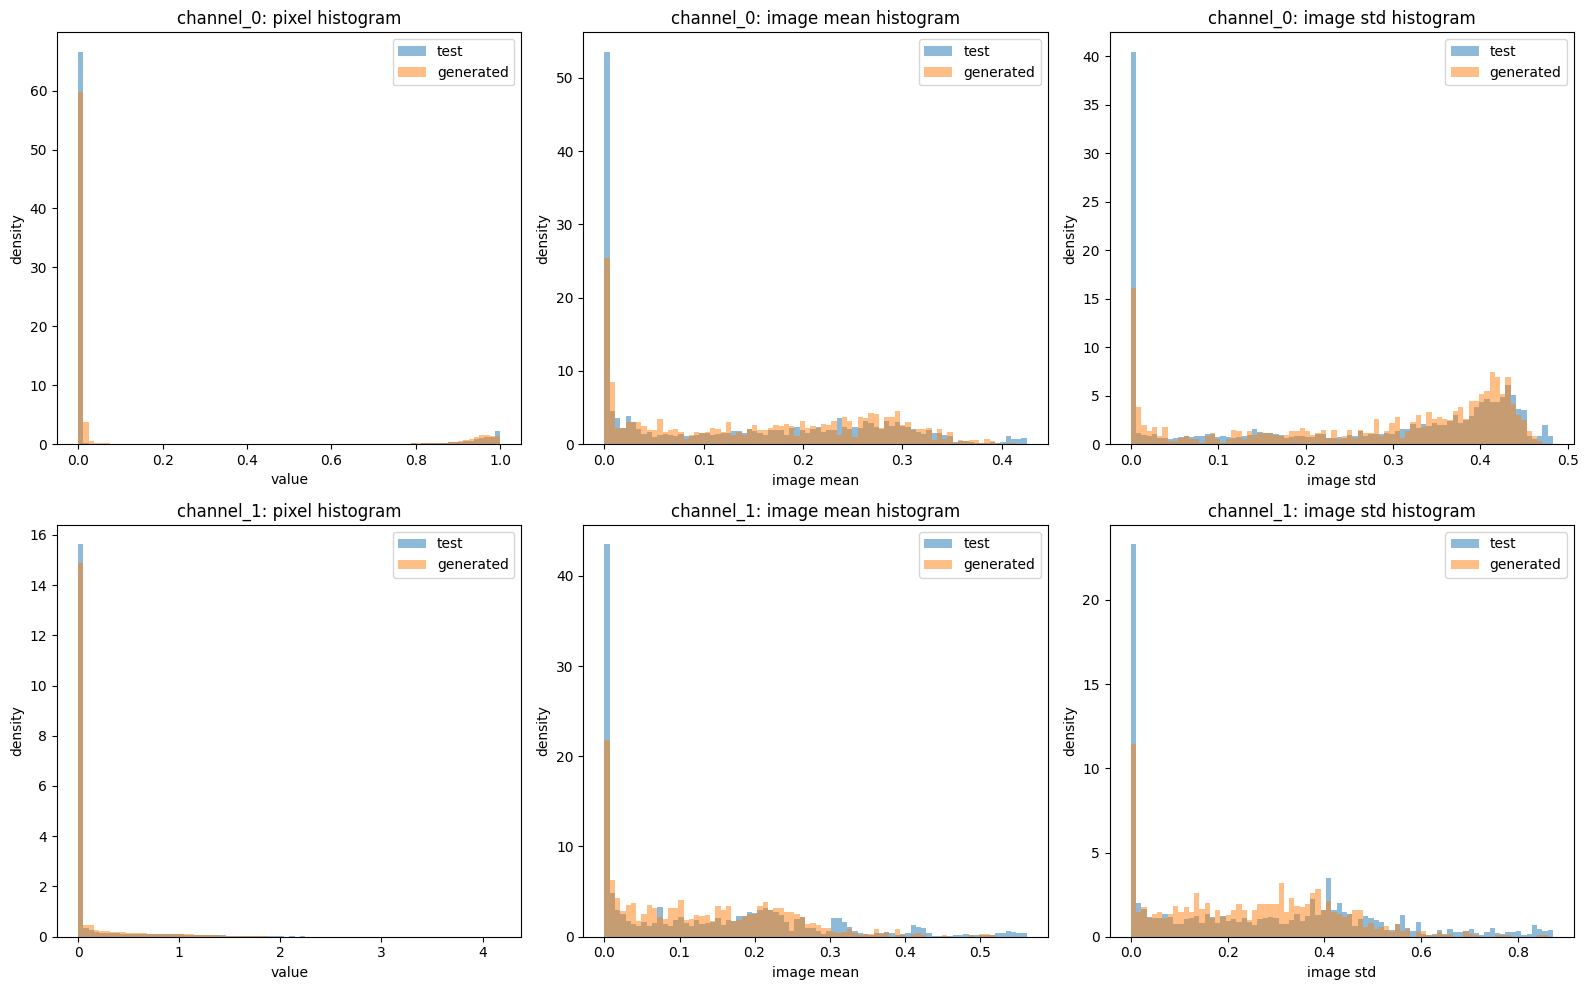

In [11]:
fig, axes = plt.subplots(n_channels, 3, figsize=(16, 5 * n_channels))
axes = np.atleast_2d(axes)

for ch in range(n_channels):
    ax = axes[ch, 0]
    data_min = min(pixel_plot_real[ch].min(), pixel_plot_fake[ch].min())
    data_max = max(pixel_plot_real[ch].max(), pixel_plot_fake[ch].max())
    bins = np.linspace(data_min, data_max, HIST_BINS + 1)
    ax.hist(pixel_plot_real[ch], bins=bins, density=True, alpha=0.5, label='test', color='tab:blue')
    ax.hist(pixel_plot_fake[ch], bins=bins, density=True, alpha=0.5, label='generated', color='tab:orange')
    ax.set_title(f'{CHANNEL_NAMES[ch]}: pixel histogram')
    ax.set_xlabel('value')
    ax.set_ylabel('density')
    ax.legend()

    ax = axes[ch, 1]
    bins = np.linspace(
        min(image_means_real[ch].min(), image_means_fake[ch].min()),
        max(image_means_real[ch].max(), image_means_fake[ch].max()),
        HIST_BINS + 1,
    )
    ax.hist(image_means_real[ch], bins=bins, density=True, alpha=0.5, label='test', color='tab:blue')
    ax.hist(image_means_fake[ch], bins=bins, density=True, alpha=0.5, label='generated', color='tab:orange')
    ax.set_title(f'{CHANNEL_NAMES[ch]}: image mean histogram')
    ax.set_xlabel('image mean')
    ax.set_ylabel('density')
    ax.legend()

    ax = axes[ch, 2]
    bins = np.linspace(
        min(image_stds_real[ch].min(), image_stds_fake[ch].min()),
        max(image_stds_real[ch].max(), image_stds_fake[ch].max()),
        HIST_BINS + 1,
    )
    ax.hist(image_stds_real[ch], bins=bins, density=True, alpha=0.5, label='test', color='tab:blue')
    ax.hist(image_stds_fake[ch], bins=bins, density=True, alpha=0.5, label='generated', color='tab:orange')
    ax.set_title(f'{CHANNEL_NAMES[ch]}: image std histogram')
    ax.set_xlabel('image std')
    ax.set_ylabel('density')
    ax.legend()

plt.tight_layout()


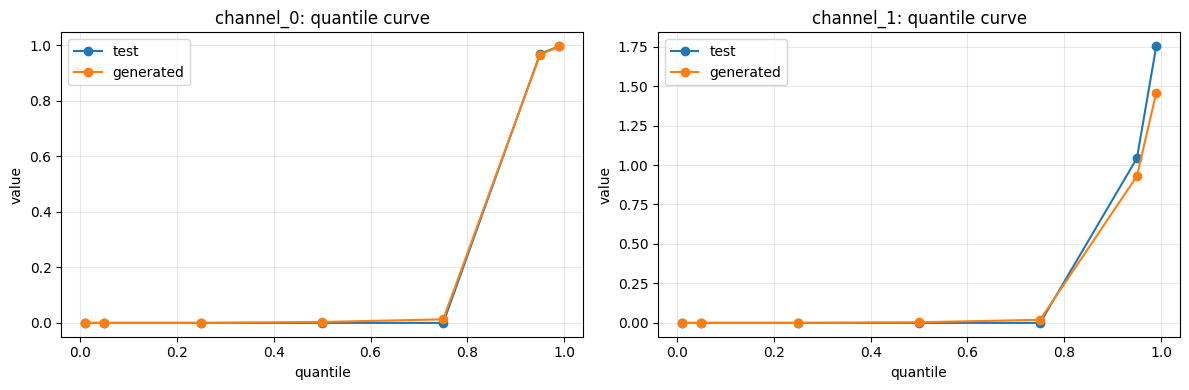

In [9]:
fig, axes = plt.subplots(1, n_channels, figsize=(6 * n_channels, 4))
axes = np.atleast_1d(axes)

for ch in range(n_channels):
    channel_quantiles = quantile_df[quantile_df['channel'] == CHANNEL_NAMES[ch]]
    axes[ch].plot(channel_quantiles['quantile'], channel_quantiles['real'], marker='o', label='test')
    axes[ch].plot(channel_quantiles['quantile'], channel_quantiles['fake'], marker='o', label='generated')
    axes[ch].set_title(f'{CHANNEL_NAMES[ch]}: quantile curve')
    axes[ch].set_xlabel('quantile')
    axes[ch].set_ylabel('value')
    axes[ch].grid(alpha=0.3)
    axes[ch].legend()

plt.tight_layout()
